# Elmer Capacitance Extraction of an Interdigital Capacitor

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra and the Elmer driver from `gplugins`:

```bash
uv add "qpdk[models]" "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@4ac6063ebfc01473a2f514b460d6f3ff04f5a17d"
# or with pip:
pip install "qpdk[models]" "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@4ac6063ebfc01473a2f514b460d6f3ff04f5a17d"
```

The Elmer driver changes are currently in the companion
[gplugins pull request](https://github.com/gdsfactory/gplugins/pull/781); the install
commands pin the revision tested with this notebook until a release includes it.

**Elmer is an external solver.** `ElmerGrid` and `ElmerSolver` must be available on your
`PATH`; they are not pip-installable. See the
[Elmer FEM installation guide](https://www.elmerfem.org/blog/binaries/) for binaries and
container options.

See the {ref}`extras reference <notebook-extras>` for what each qpdk extra installs.
::::

This notebook runs a quasi-static electrostatic solve with Elmer FEM to extract the
capacitance of a QPDK interdigital capacitor. Elmer solves
:math:`\nabla \cdot (\epsilon \nabla \phi) = 0` with a fixed potential on each metal
terminal. Elmer's `.dat` result is the lumped (circuit) capacitance matrix;
`gplugins` converts it to a Maxwell matrix, with negative off-diagonal entries, in
`ElectrostaticResults`.

## Physics

An interdigital capacitor (IDC) is two interleaved combs of metal fingers. Each comb is
a separate conductor (terminal), and the capacitance we care about is the coupling
between them.

For :math:`N` conductors Elmer's `.dat` result is the lumped (circuit) capacitance
matrix. `gplugins` converts it to the Maxwell form :math:`C` reported in
`ElectrostaticResults`, defined by :math:`Q_i = \sum_j C_{ij} V_j` with negative
off-diagonal entries:

$$ C_{ij} = -C_{ij}^{\text{mutual}} \quad (i \neq j). $$

So for a two-terminal device the mutual capacitance is
:math:`C_{12}^{\text{mutual}} = -C_{12}`, and it shows up as a **negative** off-diagonal
entry. This model has **no grounded conductor**: the diagonal entries are not independent
capacitances-to-ground, and :math:`C_{11}` and :math:`C_{22}` are effectively equal to the
mutual :math:`|C_{12}|`. All Elmer output is in SI units (farads); we convert to
femtofarads below.

This is a 3D FEM result only. It is **not benchmarked against an analytic IDC model**,
and no analytic formula is evaluated here.

## Setup and Imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
        "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@4ac6063ebfc01473a2f514b460d6f3ff04f5a17d",
    ])

In [2]:
import tempfile
from pathlib import Path

import gdsfactory as gf
import numpy as np
from gdsfactory.technology import LayerLevel, LayerStack
from meshwell.resolution import ConstantInField

from qpdk import PDK
from qpdk.cells.capacitor import interdigital_capacitor
from qpdk.tech import LAYER, material_properties

PDK.activate()

## Simulation Geometry

We use the QPDK `interdigital_capacitor` geometry with
a small number of fingers to keep the mesh and solve cheap.

Two details matter for a valid capacitance extraction:

1. **Two isolated terminals.** The capacitor must present two disconnected metal
   polygons. QPDK's IDC draws its metal on `M1_DRAW` (the additive mask) and an
   enclosing rectangle on `M1_ETCH` (the subtractive mask). We pass `etch_layer=None` so
   the component contains only the two `M1_DRAW` combs: nothing can merge them into one
   conductor.
2. **A domain outline for the dielectrics.** The substrate and air prisms are built from
   an explicit outline, drawn on the non-fabrication `SIM_AREA` layer.

We deliberately do **not** reuse `PDK.layer_stack` here. In QPDK the `M1` level is a
`DerivedLayer` built from `SIM_AREA`, `M1_ETCH` and `M1_DRAW` (metal is reconstructed
wherever `SIM_AREA` is not etched). Fed a bare capacitor component that derived layer
either resolves to nothing (no `SIM_AREA` shape) or rebuilds the whole `SIM_AREA` region
as one conductor, which would short both terminals into a full-plane `M1`. A minimal
stack whose metal level *is* `LAYER.M1_DRAW` keeps exactly the two terminal polygons the
component draws.

The outer substrate and vacuum faces use Elmer's natural zero-normal-flux boundary
condition. The finite domain and this boundary condition affect the extracted value.

Bounding box: (-28,-23;28,23)
Terminals: ['o1', 'o2']


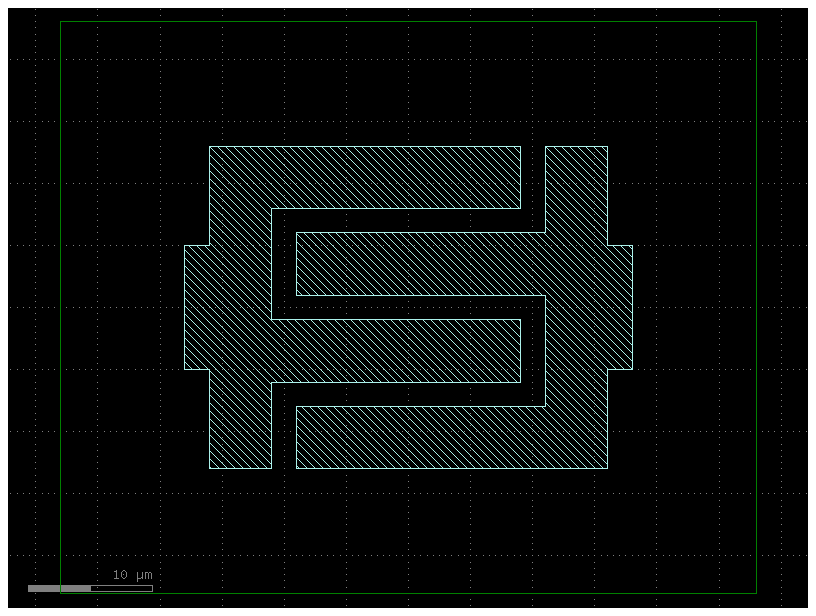

In [3]:
@gf.cell
def interdigital_capacitor_for_elmer(
    fingers: int = 4,
    finger_length: float = 20.0,
    finger_gap: float = 2.0,
    thickness: float = 5.0,
    domain_pad: float = 10.0,
) -> gf.Component:
    """Two-terminal IDC plus a `SIM_AREA` outline for the dielectric prisms.

    Args:
        fingers: Total number of interleaved fingers.
        finger_length: Length of each finger in μm.
        finger_gap: Gap between adjacent fingers in μm.
        thickness: Finger width in μm.
        domain_pad: Lateral padding of the simulation outline around the metal in μm.

    Returns:
        Component with two isolated `M1_DRAW` terminals (ports ``o1`` and ``o2``) and a
        `SIM_AREA` rectangle marking the substrate/air footprint.
    """
    c = gf.Component()
    idc = c << interdigital_capacitor(
        fingers=fingers,
        finger_length=finger_length,
        finger_gap=finger_gap,
        thickness=thickness,
        etch_layer=None,  # keep the two combs as separate M1_DRAW polygons
    )
    c.add_ports(idc.ports)

    # Flatten so the terminals are plain polygons in one cell, as the mesher expects.
    c.flatten()
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(c.bbox().enlarged(domain_pad, domain_pad))
    return c


component = interdigital_capacitor_for_elmer()
component.plot()
print(f"Bounding box: {component.bbox()}")
print(f"Terminals: {[port.name for port in component.ports]}")

## Layer Stack and Materials

The stack uses a thin Nb film on a $30\,\mu m$ Si substrate. A $20\,\mu m$
vacuum prism starts at the substrate surface to fill the gaps beside the film;
meshwell cuts the higher-priority metal out of that prism. This compact domain keeps
the example quick; increase the domain and refine the mesh before treating the
reported capacitance as a precision result.

Material permittivities come from the QPDK technology definition
(`qpdk.tech.material_properties`): Si uses :math:`\epsilon_r = 11.45`, and the niobium
film is treated as a perfect conductor.

In [4]:
metal_thickness = 0.2  # µm, a 200 nm Nb film
substrate_thickness = 30.0  # µm
air_thickness = 20.0  # µm

layer_stack = LayerStack(
    layers={
        "metal": LayerLevel(
            name="metal",
            layer=LAYER.M1_DRAW,
            thickness=metal_thickness,
            zmin=substrate_thickness,
            material="Nb",
            mesh_order=2,
        ),
        "substrate": LayerLevel(
            name="substrate",
            layer=LAYER.SIM_AREA,
            thickness=substrate_thickness,
            zmin=0.0,
            material="Si",
            mesh_order=4,
        ),
        "vacuum": LayerLevel(
            name="vacuum",
            layer=LAYER.SIM_AREA,
            thickness=air_thickness,
            zmin=substrate_thickness,
            material="vacuum",
            mesh_order=99,
        ),
    }
)

material_spec = material_properties

print("Layer stack:")
for name, level in layer_stack.layers.items():
    print(
        f"  {name:>9}: z = {level.zmin:+.2f} … {level.zmin + level.thickness:+.2f} µm, "
        f"material = {level.material}"
    )

Layer stack:
      metal: z = +30.00 … +30.20 µm, material = Nb
  substrate: z = +0.00 … +30.00 µm, material = Si
     vacuum: z = +30.00 … +50.00 µm, material = vacuum


## Mesh Settings

`mesh_parameters` is forwarded to `meshwell.mesh.mesh`. Resolution is controlled with the
current `resolution_specs` API: each key is a physical prism name, and each value is a
list of resolution objects. The driver splits the metal into `metal@o1` and `metal@o2`.
`ConstantInField` is the simplest one and pins a uniform element size. The
metal surfaces are meshed finely because the finger gaps (2 μm) carry most of the
coupling; the bulk dielectric only needs to resolve the field far from the metal.

`default_characteristic_length` sets the size everywhere else.

In [5]:
mesh_parameters = {
    "default_characteristic_length": 8.0,  # μm
    "resolution_specs": {
        "metal@o1": [
            ConstantInField(resolution=0.5, apply_to="curves"),
            ConstantInField(resolution=0.5, apply_to="surfaces"),
        ],
        "metal@o2": [
            ConstantInField(resolution=0.5, apply_to="curves"),
            ConstantInField(resolution=0.5, apply_to="surfaces"),
        ],
        "substrate": [
            ConstantInField(resolution=3.0, apply_to="surfaces"),
            ConstantInField(resolution=8.0, apply_to="volumes"),
        ],
        "vacuum": [
            ConstantInField(resolution=3.0, apply_to="surfaces"),
            ConstantInField(resolution=8.0, apply_to="volumes"),
        ],
    },
}

# Each solve keeps its mesh and field files in a separate scratch directory.
simulation_folder = Path(tempfile.mkdtemp(prefix="qpdk_elmer_interdigital_capacitor_"))
print("Elmer mesh and field files go to a fresh temporary scratch directory.")

Elmer mesh and field files go to a fresh temporary scratch directory.


## Solve

We call `run_capacitive_simulation_elmer` with the default first-order elements and a
single process. Each port becomes a terminal held at a fixed potential; both combs carry
a port, so no metal surface is grounded and the model has no grounded conductor. The
solve writes the Elmer SIF, runs `ElmerGrid` and `ElmerSolver`, and returns an
`ElectrostaticResults` whose `capacitance_matrix` holds the converted Maxwell matrix,
keyed by the port names.

In [6]:
from gplugins.elmer import run_capacitive_simulation_elmer

results = run_capacitive_simulation_elmer(
    component,
    element_order=1,
    n_processes=1,
    layer_stack=layer_stack,
    material_spec=material_spec,
    simulation_folder=simulation_folder,
    mesh_parameters=mesh_parameters,
)

## Capacitance Matrix

The Maxwell capacitance matrix is assembled in the component's port order, so the
terminals are exactly `o1` and `o2`.

In [7]:
terminals = tuple(port.name for port in component.ports)
if terminals != ("o1", "o2"):
    raise ValueError(f"unexpected terminals: {terminals}")

capacitance_raw = np.array([
    [results.capacitance_matrix[i, j] for j in terminals] for i in terminals
])
capacitance_fF = capacitance_raw * 1e15  # F -> fF

print("Maxwell capacitance matrix (raw, F):")
print(capacitance_raw)
print("\nMaxwell capacitance matrix (fF):")
print(capacitance_fF)
print(f"\nCapacitance matrix indexed by {terminals}")

Maxwell capacitance matrix (raw, F):
[[ 1.43372955e-14 -1.43372955e-14]
 [-1.43372955e-14  1.43372955e-14]]

Maxwell capacitance matrix (fF):
[[ 14.33729546 -14.33729546]
 [-14.33729546  14.33729546]]

Capacitance matrix indexed by ('o1', 'o2')


The off-diagonal entry is negative by the Maxwell convention
(:math:`C_{ij} = -C_{ij}^{\text{mutual}}`), so the mutual capacitance between the two
combs is its negative. There is no grounded conductor, so :math:`C_{11}` and
:math:`C_{22}` are not independent capacitances-to-ground; we report the mutual value.

In [8]:
c12_fF = float(capacitance_fF[0, 1])
mutual_fF = -c12_fF

print(f"Off-diagonal C12: {c12_fF:.3f} fF")
print(f"Mutual capacitance C12_mutual = -C12: {mutual_fF:.3f} fF")

Off-diagonal C12: -14.337 fF
Mutual capacitance C12_mutual = -C12: 14.337 fF


## Lateral Domain Sensitivity

The extraction above pads the simulation outline by only 10 μm, so the outer boundary
may truncate field lines that should extend further. Below we rebuild the same geometry
with a 30 μm lateral pad and re-solve with the same layer stack, materials and mesh
settings, comparing the mutual capacitance.

This comparison changes the lateral boundary and the generated mesh, so the difference
mixes domain and discretization effects. It does not establish convergence of the
vertical extent or the mesh.

In [9]:
component_wide = interdigital_capacitor_for_elmer(domain_pad=30.0)
simulation_folder_wide = Path(
    tempfile.mkdtemp(prefix="qpdk_elmer_interdigital_capacitor_wide_")
)

results_wide = run_capacitive_simulation_elmer(
    component_wide,
    element_order=1,
    n_processes=1,
    layer_stack=layer_stack,
    material_spec=material_spec,
    simulation_folder=simulation_folder_wide,
    mesh_parameters=mesh_parameters,
)

terminals_wide = tuple(port.name for port in component_wide.ports)
if terminals_wide != terminals:
    raise ValueError(f"unexpected wide-domain terminals: {terminals_wide}")
capacitance_wide_fF = (
    np.array([
        [results_wide.capacitance_matrix[i, j] for j in terminals_wide]
        for i in terminals_wide
    ])
    * 1e15
)
mutual_wide_fF = -float(capacitance_wide_fF[0, 1])

In [10]:
print(f"Mutual capacitance at domain_pad=10.0 μm: {mutual_fF:.3f} fF")
print(f"Mutual capacitance at domain_pad=30.0 μm: {mutual_wide_fF:.3f} fF")
print(f"Relative change: {(mutual_wide_fF - mutual_fF) / mutual_fF:+.2%}")

Mutual capacitance at domain_pad=10.0 μm: 14.337 fF
Mutual capacitance at domain_pad=30.0 μm: 14.520 fF
Relative change: +1.28%


## Sanity Checks

Both solves must give finite, symmetric Maxwell matrices with a positive diagonal,
negative off-diagonal and near-zero row sums. With no grounded conductor, `C11` and
`C22` duplicate the mutual term. The broad 5–40 fF range brackets earlier 14–15 fF
solves of this exact geometry; it guards against order-of-magnitude regressions, not
model accuracy.

In [11]:
for domain_pad, matrix, mutual in (
    (10.0, capacitance_fF, mutual_fF),
    (30.0, capacitance_wide_fF, mutual_wide_fF),
):
    if not np.isfinite(matrix).all():
        raise ValueError(f"{domain_pad} μm matrix has non-finite entries")
    if not np.allclose(matrix, matrix.T, rtol=1e-2, atol=1e-3):
        raise ValueError(f"{domain_pad} μm matrix is not symmetric")
    if not (np.diag(matrix) > 0).all():
        raise ValueError(f"{domain_pad} μm matrix diagonal must be positive")
    if matrix[0, 1] >= 0 or matrix[1, 0] >= 0:
        raise ValueError(f"{domain_pad} μm Maxwell off-diagonals must be negative")
    if not 5.0 < mutual < 40.0:
        raise ValueError(
            f"{domain_pad} μm mutual capacitance outside 5–40 fF: {mutual}"
        )
    if (np.abs(matrix.sum(axis=1)) > 0.01 * mutual).any():
        raise ValueError(f"{domain_pad} μm matrix has nonzero row sums")

print("All checks passed.")

All checks passed.


## Summary

We extracted the quasi-static capacitance of a QPDK interdigital capacitor with Elmer:

- Built a two-terminal geometry from `qpdk.cells.capacitor.interdigital_capacitor`,
  disabling its `M1_ETCH` mask so the two `M1_DRAW` combs stay isolated, and a minimal
  `M1_DRAW`-based layer stack to sidestep QPDK's derived `M1` level.
- Meshed a $30\,\mu m$ substrate and $20\,\mu m$ air region with `meshwell`,
  refining only the metal surfaces.
- Solved the electrostatic problem, converted Elmer's lumped result to the 2x2 Maxwell
  matrix, and reported the mutual capacitance :math:`-C_{12}`. With no grounded
  conductor, `C11` and `C22` are not independent capacitances-to-ground.
- Re-ran the solve with a 30 μm lateral pad. The observed change also includes mesh
  discretization effects, so it is a sensitivity check rather than a convergence claim.

The result is a 3D FEM number only and is not benchmarked against an analytic IDC model.

The same layout can be swept or optimized by varying `fingers`, `finger_length` and
`finger_gap` in `interdigital_capacitor_for_elmer` and re-running the solve.